In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmentYolov8/tumorSegmentYolov8/README.txt
/kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmentYolov8/tumorSegmentYolov8/data.yaml
/kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmentYolov8/tumorSegmentYolov8/valid/labels/y1236_jpg.rf.e03737cca3fff5bf88fcb0a21c77b016.txt
/kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmentYolov8/tumorSegmentYolov8/valid/labels/y551_jpg.rf.b1d2edfc32ea6ffac47d7058e489e8e9.txt
/kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmentYolov8/tumorSegmentYolov8/valid/labels/y84_jpg.rf.016c7a2cc3a1d9cc98468c4a4194791a.txt
/kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmentYolov8/tumorSegmentYolov8/valid/labels/y534_jpg.rf.8a55d58e0918147e3a20c82ddd271a44.txt
/kaggle/input/datasets/pkdara

In [2]:
!pip install torch torchvision opencv-python albumentations

In [3]:
import os
import cv2
import numpy as np
import torch

from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.transforms import functional as F

In [4]:
class BrainTumorDataset(Dataset):

    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_path = os.path.join(self.image_dir,self.images[idx])
        mask_path = os.path.join(self.mask_dir,self.masks[idx])

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path,0)

        # Binary mask
        mask = (mask>0).astype(np.uint8)

        # Connected Components
        num_labels, labels = cv2.connectedComponents(mask)

        masks=[]
        boxes=[]

        for i in range(1,num_labels):

            instance=(labels==i).astype(np.uint8)

            if instance.sum()==0:
                continue

            y,x=np.where(instance)

            xmin=x.min()
            xmax=x.max()

            ymin=y.min()
            ymax=y.max()

            boxes.append([xmin,ymin,xmax,ymax])

            masks.append(instance)

        if len(masks)==0:

            masks=np.zeros((0,*mask.shape),dtype=np.uint8)

            boxes=torch.zeros((0,4),dtype=torch.float32)

        else:

            masks=np.stack(masks)

            boxes=torch.as_tensor(boxes,dtype=torch.float32)

        labels_tensor=torch.ones((len(boxes),),dtype=torch.int64)

        masks=torch.as_tensor(masks,dtype=torch.uint8)

        image=F.to_tensor(image)

        target={}
        target["boxes"]=boxes
        target["labels"]=labels_tensor
        target["masks"]=masks
        target["image_id"]=torch.tensor([idx])

        return image,target

In [6]:
train_dataset = BrainTumorDataset(
    image_dir="/kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmYolov9/tumorSegmYolov9/train/images",
    mask_dir="/kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmYolov9/tumorSegmYolov9/train/labels"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

In [1]:
!pip install ultralytics
from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.2 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
model = YOLO("yolov8m-seg.pt")

In [3]:
model.train(
    data="/kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmYolov9/tumorSegmYolov9/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    device=0
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmYolov9/tumorSegmYolov9/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yol

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ff3d92a6570>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04

In [4]:
metrics = model.val()

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,224,121 parameters, 0 gradients, 104.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.2±0.4 ms, read: 23.5±11.3 MB/s, size: 26.6 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmYolov9/tumorSegmYolov9/valid/labels... 349 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 349/349 708.8it/s 0.5s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmYolov9/tumorSegmYolov9/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 1.5it/s 14.9s0.6s
      

In [6]:
results = model.predict(
    source="/kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmYolov9/tumorSegmYolov9/test/images",
    save=True,
    conf=0.25
)


image 1/183 /kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmYolov9/tumorSegmYolov9/test/images/y1006_jpg.rf.42a68ba23050eeb7e2a6144dd363c5a7.jpg: 640x640 1 tumor_good_chance, 45.6ms
image 2/183 /kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmYolov9/tumorSegmYolov9/test/images/y1008_jpg.rf.145bfbaa2ceb51e63ed3d04d99e896bd.jpg: 640x640 1 tumor_good_chance, 42.7ms
image 3/183 /kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmYolov9/tumorSegmYolov9/test/images/y1015_jpg.rf.b99bd499d0ec39af4023498c0a9c8332.jpg: 640x640 1 tumor_moderate_chance, 42.7ms
image 4/183 /kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmYolov9/tumorSegmYolov9/test/images/y1025_jpg.rf.9684fa8abbbfe6bf38bea0e1446eace8.jpg: 640x640 1 tumor_good_chance, 42.7ms
image 5/183 /kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmYolov9/

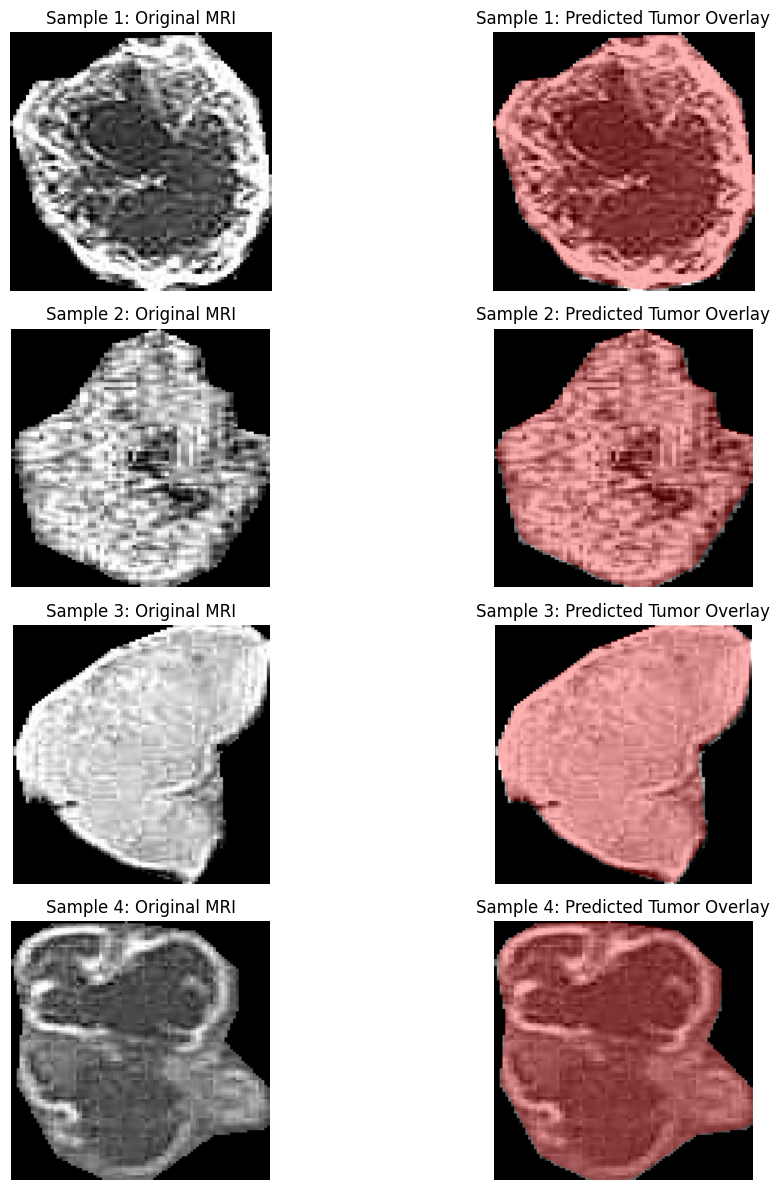

In [8]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

results = model.predict(
    source="/kaggle/input/datasets/pkdarabi/medical-image-dataset-brain-tumor-segmentation/tumorSegmYolov9/tumorSegmYolov9/test/images",
    conf=0.25,
    verbose=False
)

num_samples = min(4, len(results))

plt.figure(figsize=(12, 12))

for i in range(num_samples):

    result = results[i]

    # Original Image
    img = cv2.cvtColor(result.orig_img, cv2.COLOR_BGR2RGB)

    # Overlay
    overlay = img.copy()

    if result.masks is not None:

        masks = result.masks.data.cpu().numpy()

        for mask in masks:

            mask = cv2.resize(
                mask,
                (img.shape[1], img.shape[0])
            )

            overlay[mask > 0.5] = [255, 0, 0]

    blended = cv2.addWeighted(
        img,
        0.7,
        overlay,
        0.3,
        0
    )

    plt.subplot(num_samples,2,2*i+1)
    plt.imshow(img)
    plt.title(f"Sample {i+1}: Original MRI")
    plt.axis("off")

    plt.subplot(num_samples,2,2*i+2)
    plt.imshow(blended)
    plt.title(f"Sample {i+1}: Predicted Tumor Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()